In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [49]:
df = pd.read_csv('./data/ncr_ride_bookings.csv')
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


    Vehicle Type  Total Rides  Cancelled Rides  Cancellation Rate (%)
0           Auto        37419             9323                  24.92
1           Bike        22517             5652                  25.10
2        Go Mini        29806             7427                  24.92
3       Go Sedan        27141             6863                  25.29
4  Premier Sedan        18111             4516                  24.94
5        Uber XL         4449             1089                  24.48
6          eBike        10557             2630                  24.91


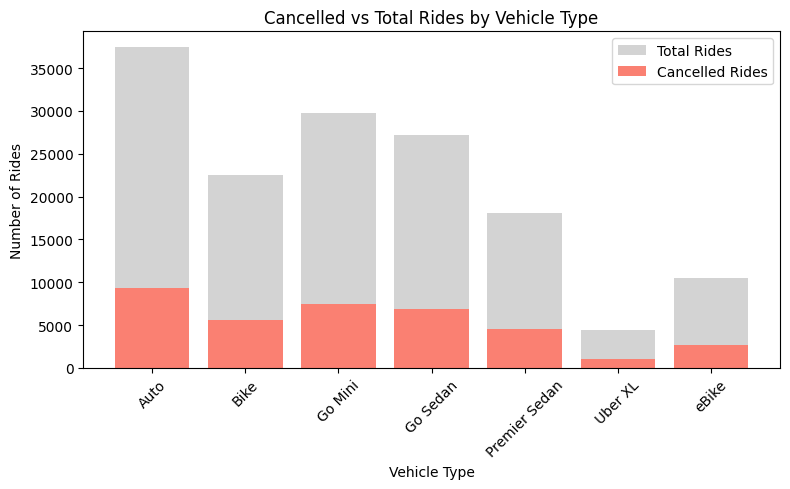

In [65]:
total_counts = (
    df.groupby('Vehicle Type')
    .size()
    .reset_index(name='Total Rides')
)

cancellation_counts = (
    df[
    (df['Booking Status'] == 'Cancelled by Customer') |
    (df['Booking Status'] == 'Cancelled by Driver')
]
    .groupby('Vehicle Type')
    .size()
    .reset_index(name='Cancelled Rides')
)

summary = pd.merge(total_counts, cancellation_counts, on='Vehicle Type', how='left').fillna(0)
summary['Cancelled Rides'] = summary['Cancelled Rides'].astype(int)

summary['Cancellation Rate (%)'] = (
    summary['Cancelled Rides'] / summary['Total Rides'] * 100
).round(2)

print(summary)

plt.figure(figsize=(8,5))
plt.bar(summary['Vehicle Type'], summary['Total Rides'], label='Total Rides', color='lightgray')
plt.bar(summary['Vehicle Type'], summary['Cancelled Rides'], label='Cancelled Rides', color='salmon')

plt.title('Cancelled vs Total Rides by Vehicle Type')
plt.ylabel('Number of Rides')
plt.xlabel('Vehicle Type')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

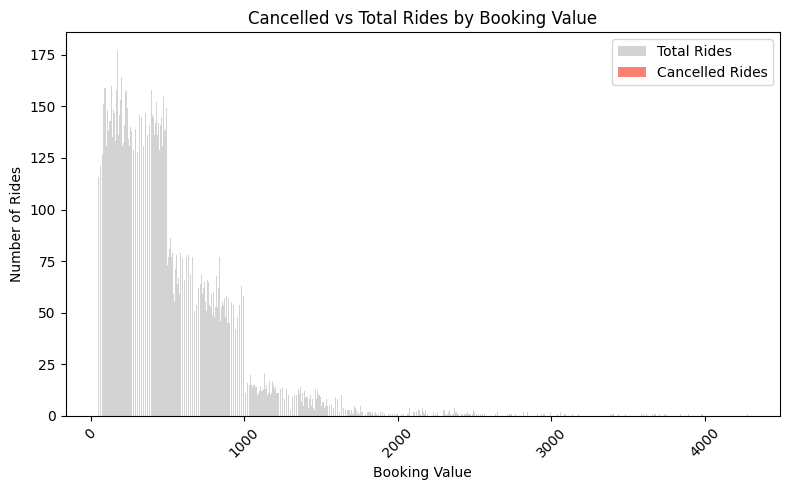

In [51]:
total_counts = (
    df.groupby('Booking Value')
    .size()
    .reset_index(name='Total Rides')
)

cancellation_counts = (
    df[
    (df['Booking Status'] == 'Cancelled by Customer') |
    (df['Booking Status'] == 'Cancelled by Driver')
]
    .groupby('Booking Value')
    .size()
    .reset_index(name='Cancelled Rides')
)

summary = pd.merge(total_counts, cancellation_counts, on='Booking Value', how='left').fillna(0)
summary['Cancelled Rides'] = summary['Cancelled Rides'].astype(int)

plt.figure(figsize=(8,5))
plt.bar(summary['Booking Value'], summary['Total Rides'], label='Total Rides', color='lightgray')
plt.bar(summary['Booking Value'], summary['Cancelled Rides'], label='Cancelled Rides', color='salmon')

plt.title('Cancelled vs Total Rides by Booking Value')
plt.ylabel('Number of Rides')
plt.xlabel('Booking Value')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

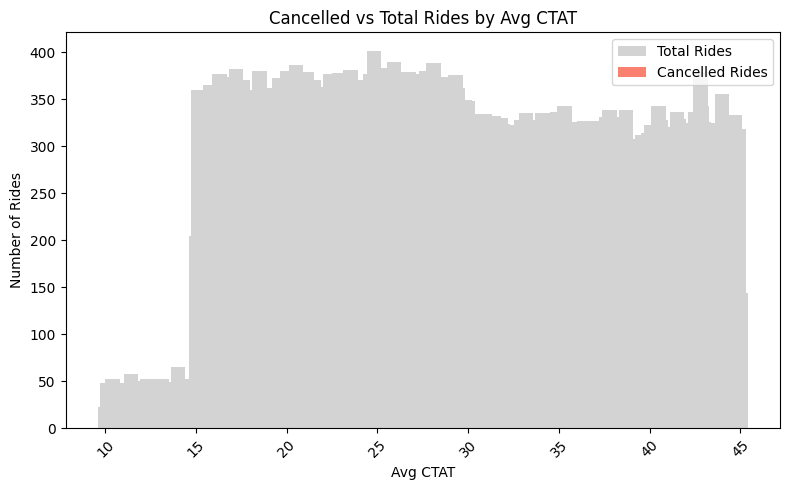

In [52]:
total_counts = (
    df.groupby('Avg CTAT')
    .size()
    .reset_index(name='Total Rides')
)

cancellation_counts = (
    df[
    (df['Booking Status'] == 'Cancelled by Customer') |
    (df['Booking Status'] == 'Cancelled by Driver')
]
    .groupby('Avg CTAT')
    .size()
    .reset_index(name='Cancelled Rides')
)

summary = pd.merge(total_counts, cancellation_counts, on='Avg CTAT', how='left').fillna(0)
summary['Cancelled Rides'] = summary['Cancelled Rides'].astype(int)

plt.figure(figsize=(8,5))
plt.bar(summary['Avg CTAT'], summary['Total Rides'], label='Total Rides', color='lightgray')
plt.bar(summary['Avg CTAT'], summary['Cancelled Rides'], label='Cancelled Rides', color='salmon')

plt.title('Cancelled vs Total Rides by Avg CTAT')
plt.ylabel('Number of Rides')
plt.xlabel('Avg CTAT')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

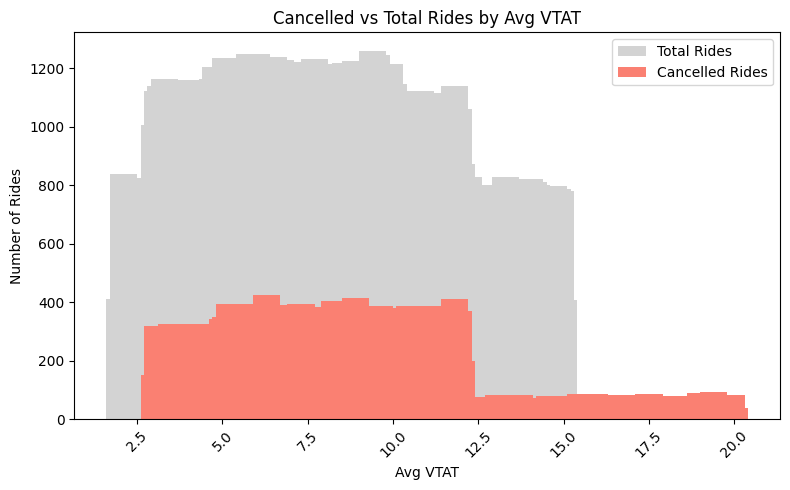

In [53]:
total_counts = (
    df.groupby('Avg VTAT')
    .size()
    .reset_index(name='Total Rides')
)

cancellation_counts = (
    df[
    (df['Booking Status'] == 'Cancelled by Customer') |
    (df['Booking Status'] == 'Cancelled by Driver')
]
    .groupby('Avg VTAT')
    .size()
    .reset_index(name='Cancelled Rides')
)

summary = pd.merge(total_counts, cancellation_counts, on='Avg VTAT', how='left').fillna(0)
summary['Cancelled Rides'] = summary['Cancelled Rides'].astype(int)

plt.figure(figsize=(8,5))
plt.bar(summary['Avg VTAT'], summary['Total Rides'], label='Total Rides', color='lightgray')
plt.bar(summary['Avg VTAT'], summary['Cancelled Rides'], label='Cancelled Rides', color='salmon')

plt.title('Cancelled vs Total Rides by Avg VTAT')
plt.ylabel('Number of Rides')
plt.xlabel('Avg VTAT')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

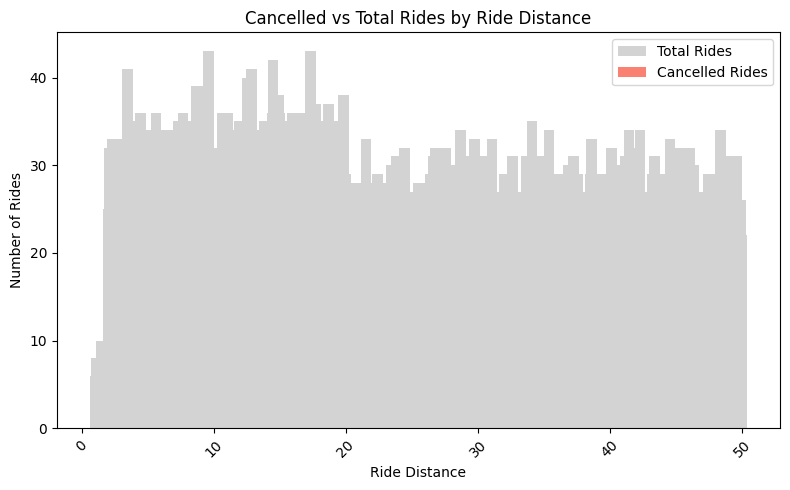

In [54]:
total_counts = (
    df.groupby('Ride Distance')
    .size()
    .reset_index(name='Total Rides')
)

cancellation_counts = (
    df[
    (df['Booking Status'] == 'Cancelled by Customer') |
    (df['Booking Status'] == 'Cancelled by Driver')
]
    .groupby('Ride Distance')
    .size()
    .reset_index(name='Cancelled Rides')
)

summary = pd.merge(total_counts, cancellation_counts, on='Ride Distance', how='left').fillna(0)
summary['Cancelled Rides'] = summary['Cancelled Rides'].astype(int)

plt.figure(figsize=(8,5))
plt.bar(summary['Ride Distance'], summary['Total Rides'], label='Total Rides', color='lightgray')
plt.bar(summary['Ride Distance'], summary['Cancelled Rides'], label='Cancelled Rides', color='salmon')

plt.title('Cancelled vs Total Rides by Ride Distance')
plt.ylabel('Number of Rides')
plt.xlabel('Ride Distance')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

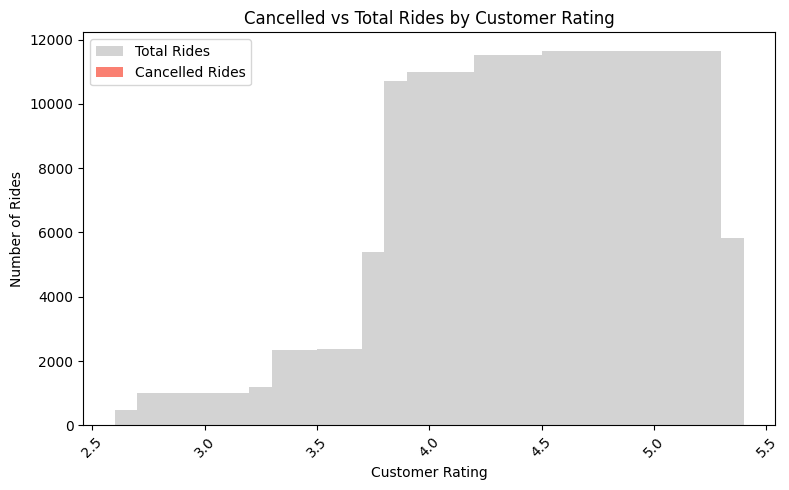

In [55]:
total_counts = (
    df.groupby('Customer Rating')
    .size()
    .reset_index(name='Total Rides')
)

cancellation_counts = (
    df[
    (df['Booking Status'] == 'Cancelled by Customer') |
    (df['Booking Status'] == 'Cancelled by Driver')
]
    .groupby('Customer Rating')
    .size()
    .reset_index(name='Cancelled Rides')
)

summary = pd.merge(total_counts, cancellation_counts, on='Customer Rating', how='left').fillna(0)
summary['Cancelled Rides'] = summary['Cancelled Rides'].astype(int)

plt.figure(figsize=(8,5))
plt.bar(summary['Customer Rating'], summary['Total Rides'], label='Total Rides', color='lightgray')
plt.bar(summary['Customer Rating'], summary['Cancelled Rides'], label='Cancelled Rides', color='salmon')

plt.title('Cancelled vs Total Rides by Customer Rating')
plt.ylabel('Number of Rides')
plt.xlabel('Customer Rating')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

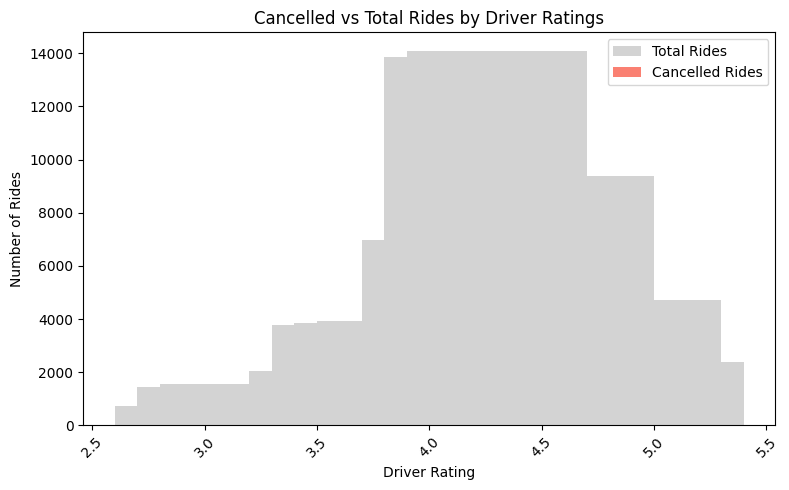

In [56]:
total_counts = (
    df.groupby('Driver Ratings')
    .size()
    .reset_index(name='Total Rides')
)

cancellation_counts = (
    df[
    (df['Booking Status'] == 'Cancelled by Customer') |
    (df['Booking Status'] == 'Cancelled by Driver')
]
    .groupby('Driver Ratings')
    .size()
    .reset_index(name='Cancelled Rides')
)

summary = pd.merge(total_counts, cancellation_counts, on='Driver Ratings', how='left').fillna(0)
summary['Cancelled Rides'] = summary['Cancelled Rides'].astype(int)

plt.figure(figsize=(8,5))
plt.bar(summary['Driver Ratings'], summary['Total Rides'], label='Total Rides', color='lightgray')
plt.bar(summary['Driver Ratings'], summary['Cancelled Rides'], label='Cancelled Rides', color='salmon')

plt.title('Cancelled vs Total Rides by Driver Ratings')
plt.ylabel('Number of Rides')
plt.xlabel('Driver Rating')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

     Pickup Location  Total Rides  Cancelled Rides  Cancellation Rate (%)
0              AIIMS          918              236                  25.71
1           Badarpur          921              231                  25.08
2    Barakhamba Road          946              230                  24.31
3   Dwarka Sector 21          914              227                  24.84
4    Greater Kailash          895              231                  25.81
5           Inderlok          887              223                  25.14
6             Jasola          887              226                  25.48
7     Kanhaiya Nagar          895              196                  21.90
8            Khandsa          949              226                  23.81
9            Madipur          919              212                  23.07
10          Mehrauli          915              224                  24.48
11     Pataudi Chowk          907              215                  23.70
12    Pragati Maidan          920     

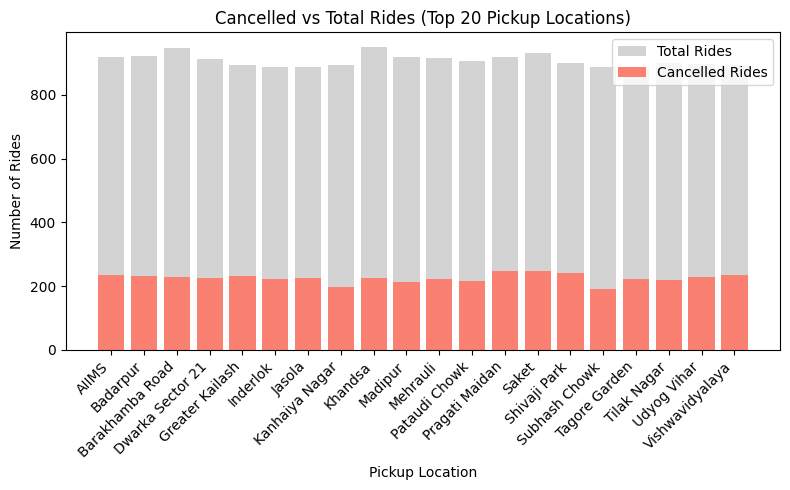

In [68]:
top_pickups = (
    df['Pickup Location']
    .value_counts()
    .head(20)
    .index
)

df_top = df[df['Pickup Location'].isin(top_pickups)]


# total rides per location
total_counts = (
    df_top.groupby('Pickup Location')
    .size()
    .reset_index(name='Total Rides')
)

# cancelled rides (not Completed)
cancellation_counts = (
    df[
    (df['Booking Status'] == 'Cancelled by Customer') |
    (df['Booking Status'] == 'Cancelled by Driver')
]
    .groupby('Pickup Location')
    .size()
    .reset_index(name='Cancelled Rides')
)

# merge them together
summary = pd.merge(total_counts, cancellation_counts, on='Pickup Location', how='left').fillna(0)
summary['Cancelled Rides'] = summary['Cancelled Rides'].astype(int)
summary['Cancellation Rate (%)'] = (summary['Cancelled Rides'] / summary['Total Rides'] * 100).round(2)

summary['Cancellation Rate (%)'] = (
    summary['Cancelled Rides'] / summary['Total Rides'] * 100
).round(2)

print(summary)

plt.figure(figsize=(8,5))
plt.bar(summary['Pickup Location'], summary['Total Rides'], label='Total Rides', color='lightgray')
plt.bar(summary['Pickup Location'], summary['Cancelled Rides'],
        label='Cancelled Rides', color='salmon')

plt.title('Cancelled vs Total Rides (Top 20 Pickup Locations)')
plt.ylabel('Number of Rides')
plt.xlabel('Pickup Location')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

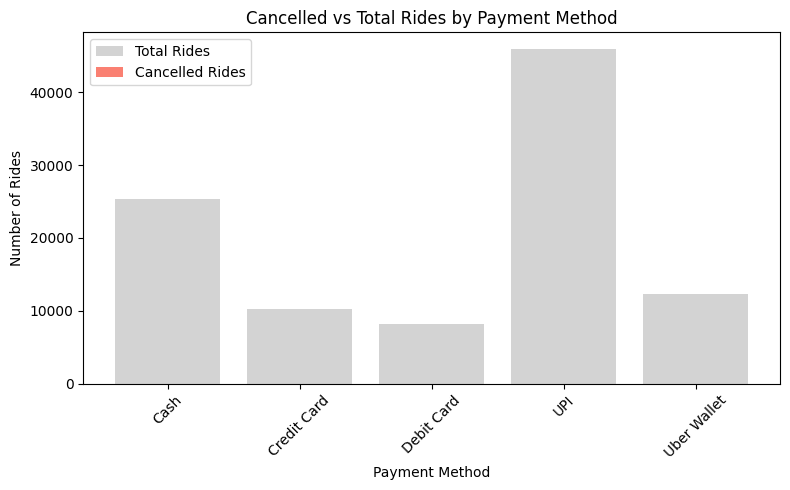

In [58]:
total_counts = (
    df.groupby('Payment Method')
    .size()
    .reset_index(name='Total Rides')
)

cancellation_counts = (
    df[
    (df['Booking Status'] == 'Cancelled by Customer') |
    (df['Booking Status'] == 'Cancelled by Driver')
]
    .groupby('Payment Method')
    .size()
    .reset_index(name='Cancelled Rides')
)

summary = pd.merge(total_counts, cancellation_counts, on='Payment Method', how='left').fillna(0)
summary['Cancelled Rides'] = summary['Cancelled Rides'].astype(int)

plt.figure(figsize=(8,5))
plt.bar(summary['Payment Method'], summary['Total Rides'], label='Total Rides', color='lightgray')
plt.bar(summary['Payment Method'], summary['Cancelled Rides'], label='Cancelled Rides', color='salmon')

plt.title('Cancelled vs Total Rides by Payment Method')
plt.ylabel('Number of Rides')
plt.xlabel('Payment Method')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

              Drop Location  Total Rides  Cancelled Rides  \
0                    Ashram          936              232   
1             Basai Dhankot          917              258   
2                 Cyber Hub          912              218   
3   Gurgaon Railway Station          891              231   
4         Gurgaon Sector 56          894              239   
5                 Hauz Khas          892              238   
6                   Kalkaji          912              239   
7        Kashmere Gate ISBT          909              220   
8              Lajpat Nagar          904              215   
9           Lok Kalyan Marg          916              234   
10                  Madipur          902              210   
11                Moolchand          899              239   
12              Narsinghpur          913              223   
13              Nehru Place          902              238   
14               New Colony          890              222   
15             Punjabi B

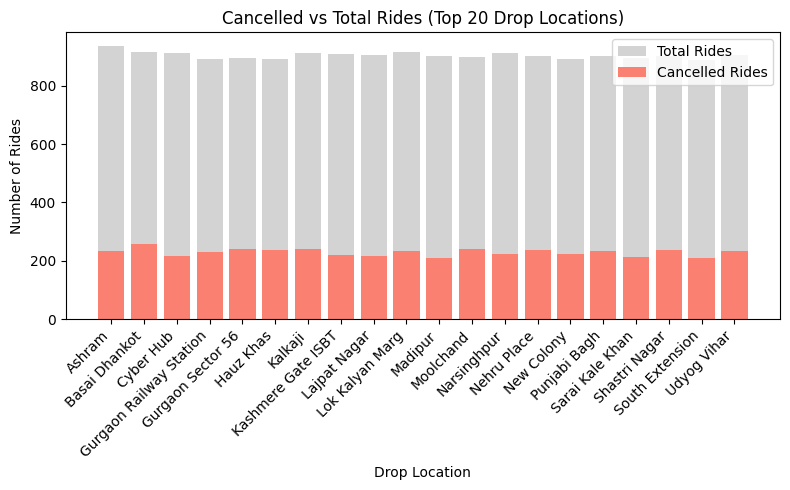

In [67]:
top_pickups = (
    df['Drop Location']
    .value_counts()
    .head(20)
    .index
)

df_top = df[df['Drop Location'].isin(top_pickups)]


total_counts = (
    df_top.groupby('Drop Location')
    .size()
    .reset_index(name='Total Rides')
)

cancellation_counts = (
    df[
    (df['Booking Status'] == 'Cancelled by Customer') |
    (df['Booking Status'] == 'Cancelled by Driver')
]
    .groupby('Drop Location')
    .size()
    .reset_index(name='Cancelled Rides')
)

summary = pd.merge(total_counts, cancellation_counts, on='Drop Location', how='left').fillna(0)
summary['Cancelled Rides'] = summary['Cancelled Rides'].astype(int)
summary['Cancellation Rate (%)'] = (summary['Cancelled Rides'] / summary['Total Rides'] * 100).round(2)

summary['Cancellation Rate (%)'] = (
    summary['Cancelled Rides'] / summary['Total Rides'] * 100
).round(2)

print(summary)

plt.figure(figsize=(8,5))
plt.bar(summary['Drop Location'], summary['Total Rides'], label='Total Rides', color='lightgray')
plt.bar(summary['Drop Location'], summary['Cancelled Rides'],
        label='Cancelled Rides', color='salmon')

plt.title('Cancelled vs Total Rides (Top 20 Drop Locations)')
plt.ylabel('Number of Rides')
plt.xlabel('Drop Location')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

     Weekday  Total Rides  Cancelled Rides  Cancellation Rate (%)
1     Monday        21644             5552                  25.65
5    Tuesday        21391             5388                  25.19
6  Wednesday        21413             5315                  24.82
4   Thursday        21215             5231                  24.66
0     Friday        21397             5343                  24.97
2   Saturday        21542             5328                  24.73
3     Sunday        21398             5343                  24.97


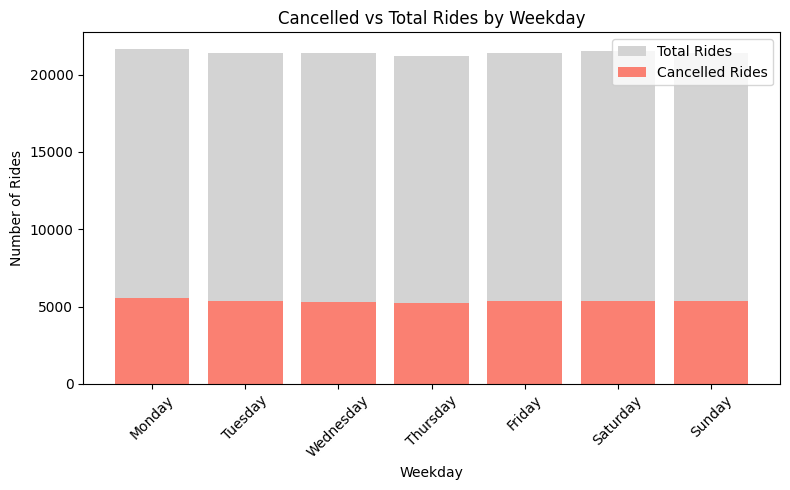

In [66]:
df['Date'] = pd.to_datetime(df['Date'])

df['Weekday'] = df['Date'].dt.day_name()

total_counts = (
    df.groupby('Weekday')
    .size()
    .reset_index(name='Total Rides')
)

cancellation_counts = (
    df[
        (df['Booking Status'] == 'Cancelled by Customer') |
        (df['Booking Status'] == 'Cancelled by Driver')
    ]
    .groupby('Weekday')
    .size()
    .reset_index(name='Cancelled Rides')
)

summary = pd.merge(total_counts, cancellation_counts, on='Weekday', how='left').fillna(0)
summary['Cancelled Rides'] = summary['Cancelled Rides'].astype(int)

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
summary['Weekday'] = pd.Categorical(summary['Weekday'], categories=weekday_order, ordered=True)
summary = summary.sort_values('Weekday')

summary['Cancellation Rate (%)'] = (
    summary['Cancelled Rides'] / summary['Total Rides'] * 100
).round(2)

print(summary)

# 7. Plot
plt.figure(figsize=(8,5))
plt.bar(summary['Weekday'], summary['Total Rides'], label='Total Rides', color='lightgray')
plt.bar(summary['Weekday'], summary['Cancelled Rides'], label='Cancelled Rides', color='salmon')

plt.title('Cancelled vs Total Rides by Weekday')
plt.ylabel('Number of Rides')
plt.xlabel('Weekday')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

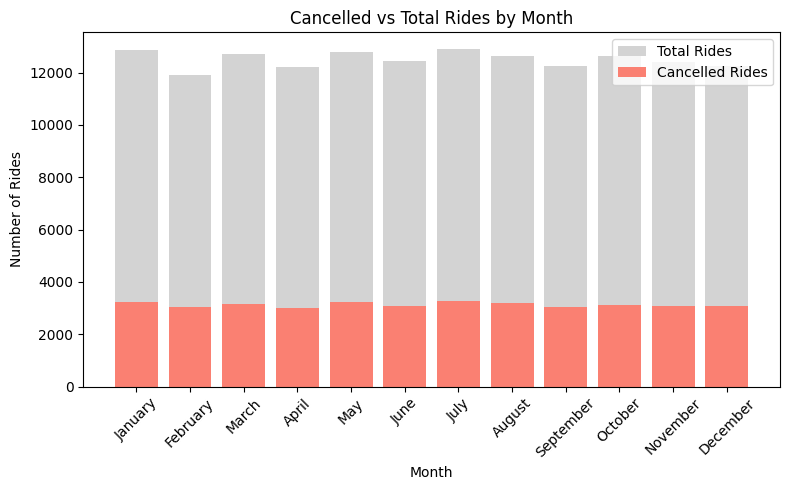

In [62]:
# 1. Make sure the Date column is datetime
df['Date'] = pd.to_datetime(df['Date'])

# 2. Extract month name
df['Month'] = df['Date'].dt.month_name()

# 3. Count total rides per month
total_counts = (
    df.groupby('Month')
    .size()
    .reset_index(name='Total Rides')
)

# 4. Count cancelled rides per month
cancellation_counts = (
    df[
        (df['Booking Status'] == 'Cancelled by Customer') |
        (df['Booking Status'] == 'Cancelled by Driver')
    ]
    .groupby('Month')
    .size()
    .reset_index(name='Cancelled Rides')
)

# 5. Merge
summary = pd.merge(total_counts, cancellation_counts, on='Month', how='left').fillna(0)
summary['Cancelled Rides'] = summary['Cancelled Rides'].astype(int)

# 6. Sort months in calendar order
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
summary['Month'] = pd.Categorical(summary['Month'], categories=month_order, ordered=True)
summary = summary.sort_values('Month')

# 7. Plot
plt.figure(figsize=(8,5))
plt.bar(summary['Month'], summary['Total Rides'], label='Total Rides', color='lightgray')
plt.bar(summary['Month'], summary['Cancelled Rides'], label='Cancelled Rides', color='salmon')

plt.title('Cancelled vs Total Rides by Month')
plt.ylabel('Number of Rides')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


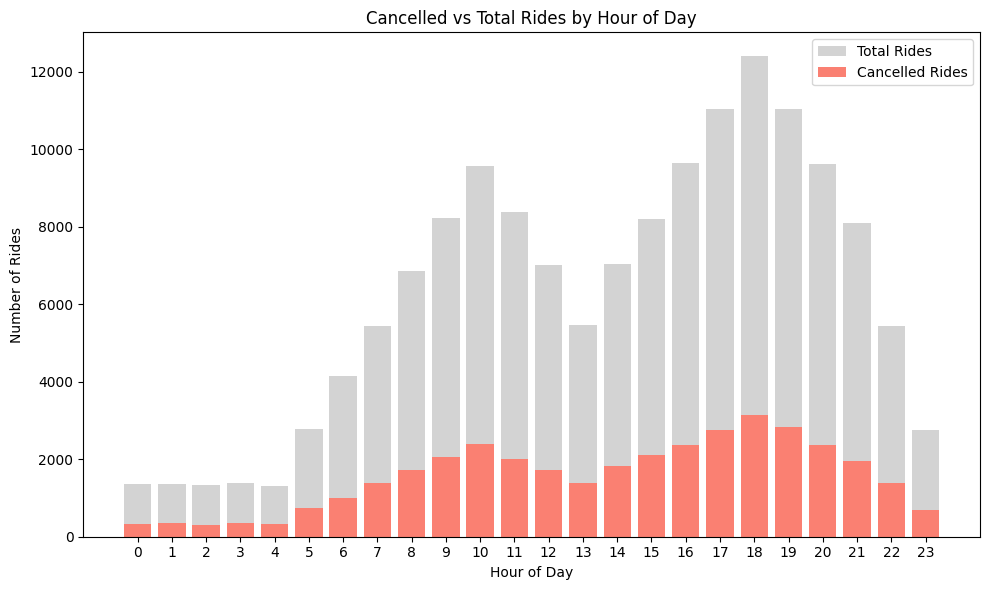

In [63]:
# 1. Ensure 'Time' is a time object
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce')

# 2. Extract the hour (0–23)
df['Hour'] = df['Time'].dt.hour

# 3. Count total rides per hour
total_counts = (
    df.groupby('Hour')
    .size()
    .reset_index(name='Total Rides')
)

# 4. Count cancelled rides per hour
cancellation_counts = (
    df[
        (df['Booking Status'] == 'Cancelled by Customer') |
        (df['Booking Status'] == 'Cancelled by Driver')
    ]
    .groupby('Hour')
    .size()
    .reset_index(name='Cancelled Rides')
)

# 5. Merge the two
summary = pd.merge(total_counts, cancellation_counts, on='Hour', how='left').fillna(0)
summary['Cancelled Rides'] = summary['Cancelled Rides'].astype(int)

# 6. Plot
plt.figure(figsize=(10,6))
plt.bar(summary['Hour'], summary['Total Rides'], label='Total Rides', color='lightgray')
plt.bar(summary['Hour'], summary['Cancelled Rides'], label='Cancelled Rides', color='salmon')

plt.title('Cancelled vs Total Rides by Hour of Day')
plt.ylabel('Number of Rides')
plt.xlabel('Hour of Day')
plt.xticks(range(0,24))
plt.legend()
plt.tight_layout()
plt.show()
